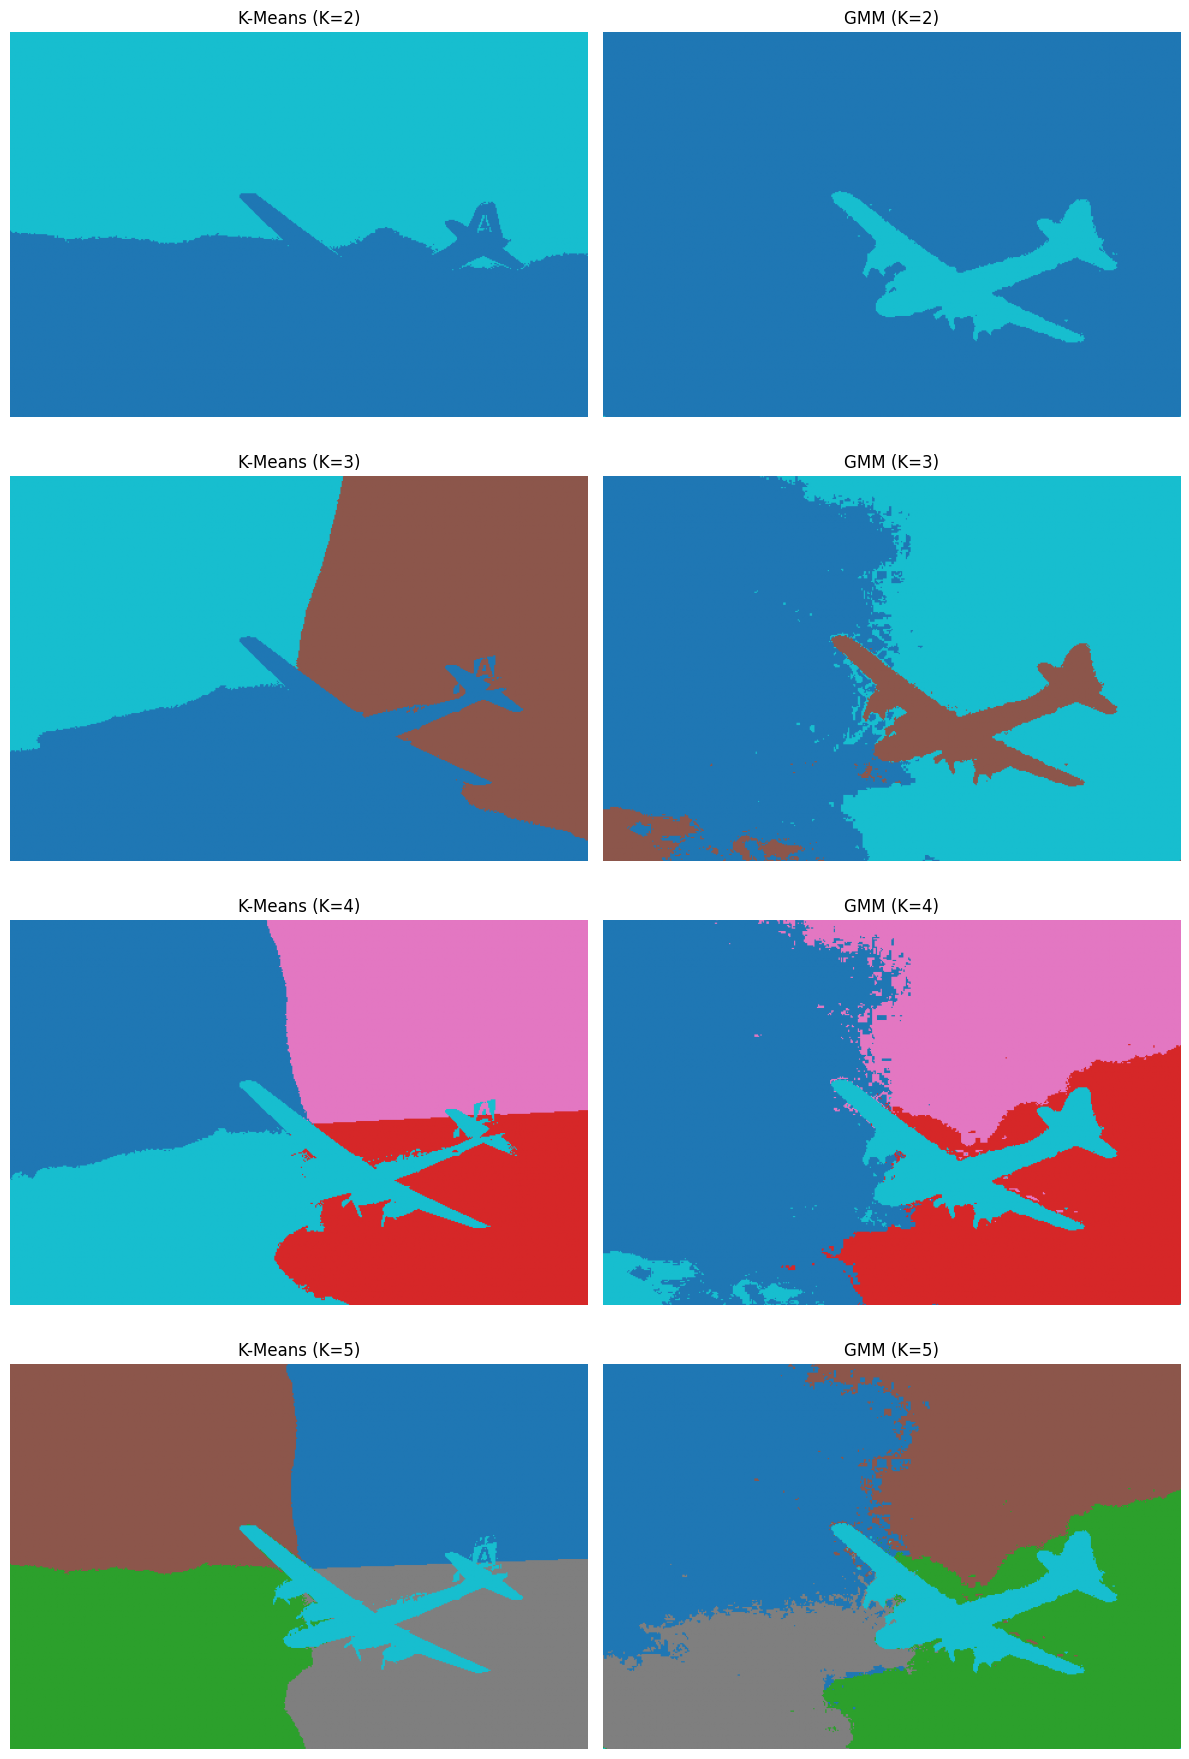

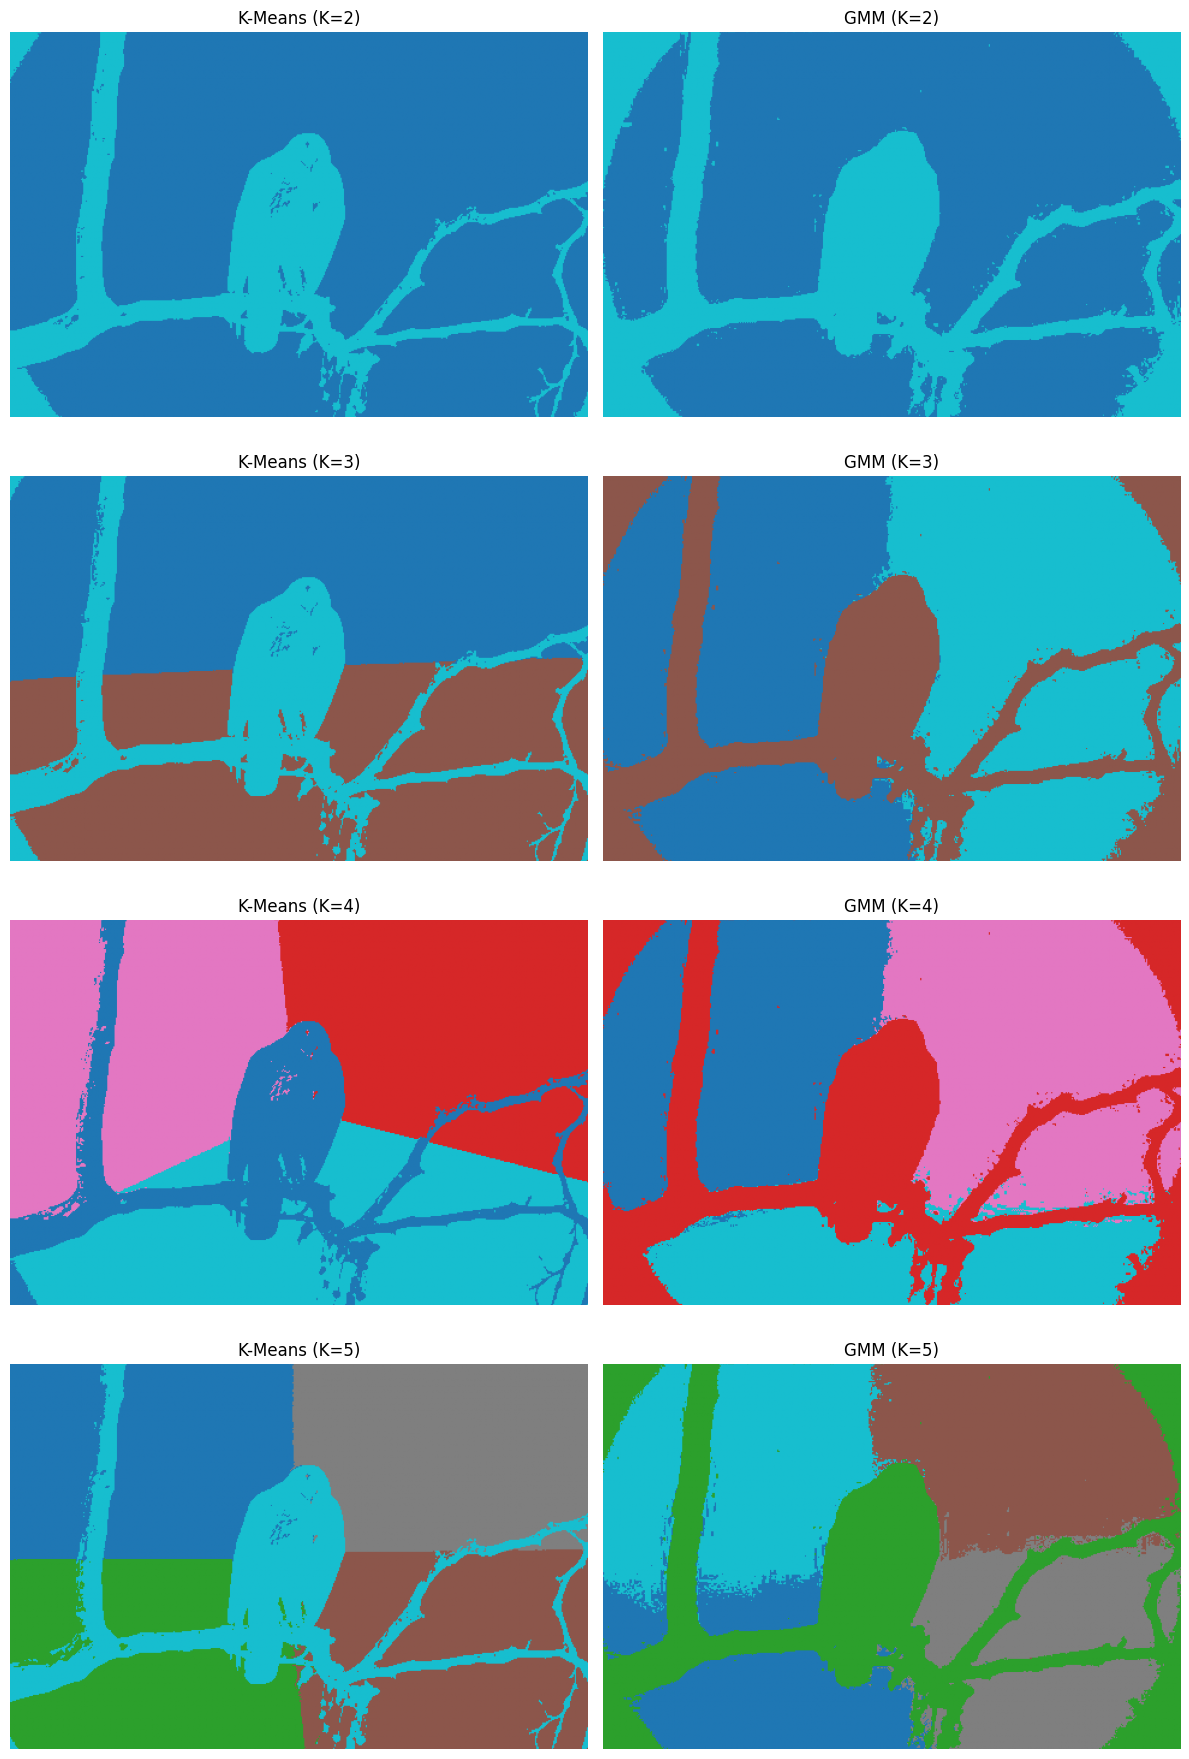

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

def segment_image_final(image_path, output_name, K_values=[2, 3, 4, 5]):
    # بارگذاری تصویر
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: {image_path} not found.")
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    # ایجاد مختصات و نرمال‌سازی در بازه [0, 1] [cite: 141, 142]
    y_coords, x_coords = np.indices((h, w))
    # ویژگی‌ها: x_norm, y_norm, R_norm, G_norm, B_norm
    features = np.stack([
        x_coords.ravel() / (w - 1),
        y_coords.ravel() / (h - 1),
        img[:,:,0].ravel() / 255.0,
        img[:,:,1].ravel() / 255.0,
        img[:,:,2].ravel() / 255.0
    ], axis=-1)

    fig, axes = plt.subplots(len(K_values), 2, figsize=(12, 18))

    for i, K in enumerate(K_values):
        # 1. K-Means clustering [cite: 140]
        kmeans = KMeans(n_clusters=K, random_state=42, n_init=10).fit(features)
        labels_km = kmeans.labels_.reshape(h, w)

        # 2. GMM clustering using EM [cite: 148]
        gmm = GaussianMixture(n_components=K, random_state=42).fit(features)
        labels_gmm = gmm.predict(features).reshape(h, w)

        # نمایش با استفاده از نقشه رنگی برای کنتراست بالا [cite: 146, 147]
        axes[i, 0].imshow(labels_km, cmap='tab10')
        axes[i, 0].set_title(f'K-Means (K={K})')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(labels_gmm, cmap='tab10')
        axes[i, 1].set_title(f'GMM (K={K})')
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.savefig(f'{output_name}_results.png')
    plt.show()


segment_image_final('image1.jpg', 'image1')
segment_image_final('image2.jpg', 'image2')